# MAGA Experiment Analysis: Parameter Impact on Validation Accuracy

This notebook provides an exhaustive analysis of the hyperparameter grid search experiments.

**Primary Metric**: `best_epoch/val/accuracy`

## Hyperparameters Analyzed

### Dataset Parameters
- `ho_init_method`: Higher-order initialization (`avg_post`, `bio`)
- `max_posts_per_user`: User post filter (1000, 2000)
- `data_seed`: Random seed for splits (1, 3, 5)

### Model Architecture Parameters
- `neighborhoods`: Topological neighborhood structure
  - **Adjacency variants**: `[1-up_adjacency-0]`, `[2-up_adjacency-0]`, `[3-up_adjacency-0]`, `[3-up_adjacency-0, 2-up_adjacency-0, 1-up_adjacency-0]`
  - **Incidence variants**: `[1-down_incidence-1]`, `[2-down_incidence-2]`, `[3-down_incidence-3]`, combined
- `ranks_to_propagate`: Signal propagation ranks (`[]`, `[1]`, `[2]`, `[3]`, `[3,2,1]`)

### Baseline Comparison
- DeepSet (no topological structure)

## 1. Setup & Data Retrieval

In [1]:
import wandb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

In [2]:
# ================================================
# CONFIGURATION - UPDATE THESE VALUES IF NEEDED
# ================================================
WANDB_ENTITY = "arlequin"  # Your wandb username or team name
WANDB_PROJECT = "MAGA_Analysis_small"  # Project name from logger.wandb.project
PROJECT_PATH = f"{WANDB_ENTITY}/{WANDB_PROJECT}"
# ================================================

print(f"Connecting to wandb project: {PROJECT_PATH}")

Connecting to wandb project: arlequin/MAGA_Analysis_small


In [3]:
# Connect to wandb and fetch runs
api = wandb.Api()

try:
    runs = api.runs(PROJECT_PATH)
    print(f"Total runs fetched: {len(runs)}")
    
    # Show run states
    states = {}
    for run in runs:
        states[run.state] = states.get(run.state, 0) + 1
    print(f"Run states: {states}")
except Exception as e:
    print(f"Error connecting to wandb: {e}")
    print("\nPossible issues:")
    print("1. Project doesn't exist yet (experiments still running)")
    print("2. Wrong project name or entity")
    print("3. Not logged in to wandb (run 'wandb login' in terminal)")

Total runs fetched: 198
Run states: {'finished': 197, 'crashed': 1}


In [4]:
def normalize_config_value(val, default='N/A'):
    """Normalize config values for consistent grouping."""
    if val is None:
        return default
    if isinstance(val, float) and (pd.isna(val) or np.isnan(val)):
        return default
    if val == '' or val == 'None':
        return default
    if isinstance(val, float):
        return round(val, 6)
    return val

# Extract data from runs
data = []

for run in runs:
    if run.state != 'finished':
        continue
    
    config = run.config
    summary = run.summary
    
    val_accuracy = summary.get('best_epoch/val/accuracy', None)
    if val_accuracy is None:
        continue
    
    try:
        # Extract all relevant parameters
        record = {
            'run_id': run.id,
            'run_name': run.name,
            'val_accuracy': val_accuracy,
            'test_accuracy': summary.get('test/accuracy', None),
            'train_accuracy': summary.get('best_epoch/train/accuracy', None),
            
            # Model architecture
            'model_name': normalize_config_value(
                config.get('model', {}).get('model_name', None), 'N/A'
            ),
            'neighborhoods': str(normalize_config_value(
                config.get('model', {}).get('backbone', {}).get('neighborhoods', None), 'N/A'
            )),
            'ranks_to_propagate': str(normalize_config_value(
                config.get('model', {}).get('readout', {}).get('ranks_to_propagate', None), 'N/A'
            )),
            'readout_name': normalize_config_value(
                config.get('model', {}).get('readout', {}).get('readout_name', None), 'N/A'
            ),
            'out_channels': normalize_config_value(
                config.get('model', {}).get('feature_encoder', {}).get('out_channels', None), 'N/A'
            ),
            'proj_dropout': normalize_config_value(
                config.get('model', {}).get('feature_encoder', {}).get('proj_dropout', None), 'N/A'
            ),
            
            # Dataset parameters
            'ho_init_method': normalize_config_value(
                config.get('dataset', {}).get('loader', {}).get('parameters', {}).get('ho_init_method', None), 'N/A'
            ),
            'max_posts_per_user': normalize_config_value(
                config.get('dataset', {}).get('loader', {}).get('parameters', {}).get('max_posts_per_user', None), 'N/A'
            ),
            'data_seed': normalize_config_value(
                config.get('dataset', {}).get('split_params', {}).get('data_seed', None), 'N/A'
            ),
            
            # Training info
            'best_epoch': summary.get('best_epoch', None),
            'lr': normalize_config_value(
                config.get('optimizer', {}).get('parameters', {}).get('lr', None), 'N/A'
            ),
        }
        data.append(record)
    except Exception as e:
        print(f"Error processing run {run.id}: {e}")
        continue

df = pd.DataFrame(data)
print(f"Successfully processed {len(df)} finished runs")
df.head()

Successfully processed 145 finished runs


,run_id,run_name,val_accuracy,test_accuracy,train_accuracy,model_name,neighborhoods,ranks_to_propagate,readout_name,out_channels,proj_dropout,ho_init_method,max_posts_per_user,data_seed,best_epoch,lr
0,cxthxpcw,noble-pond-1,0.228995,0.268092,0.258596,topotune,['3-up_adjacency-0'],[],PropagateSignalDown,128,0.25,avg_post,1000,1,3,0.001
1,8s8d7zew,mild-river-3,0.929160,0.932566,0.958205,topotune,['2-up_adjacency-0'],[],PropagateSignalDown,128,0.25,avg_post,1000,1,25,0.001
2,aldmnvng,astral-glade-2,0.902801,0.916118,0.943381,topotune,"['3-up_adjacency-0', '2-up_adjacency-0', '1-up...",[],PropagateSignalDown,128,0.25,avg_post,1000,1,26,0.001
3,ap08o0r3,polished-puddle-4,0.339374,0.351974,0.352481,topotune,['1-up_adjacency-0'],[],PropagateSignalDown,128,0.25,avg_post,1000,1,8,0.001
4,nmeuhihe,exalted-lion-6,0.936597,0.923817,0.943731,topotune,['2-up_adjacency-0'],[],PropagateSignalDown,128,0.25,avg_post,2000,1,31,0.001


## 2. Data Preprocessing & Feature Engineering

In [5]:
def parse_neighborhoods(neigh_str):
    """Convert neighborhood string to readable format and extract metadata."""
    if neigh_str == 'N/A' or neigh_str == 'None':
        return 'No Topology (Baseline)', 'none', 'none'
    
    # Adjacency patterns
    if '3-up_adjacency-0' in neigh_str and '2-up_adjacency-0' in neigh_str and '1-up_adjacency-0' in neigh_str:
        return 'All Ranks (1,2,3)', 'adjacency', 'all'
    elif '3-up_adjacency-0' in neigh_str:
        return 'Rank-3 (Community)', 'adjacency', '3'
    elif '2-up_adjacency-0' in neigh_str:
        return 'Rank-2 (Interaction)', 'adjacency', '2'
    elif '1-up_adjacency-0' in neigh_str:
        return 'Rank-1 (User)', 'adjacency', '1'
    
    # Incidence patterns
    if '3-down_incidence-3' in neigh_str and '2-down_incidence-2' in neigh_str and '1-down_incidence-1' in neigh_str:
        return 'All Ranks (1,2,3)', 'incidence', 'all'
    elif '3-down_incidence-3' in neigh_str:
        return 'Rank-3 (Community)', 'incidence', '3'
    elif '2-down_incidence-2' in neigh_str:
        return 'Rank-2 (Interaction)', 'incidence', '2'
    elif '1-down_incidence-1' in neigh_str:
        return 'Rank-1 (User)', 'incidence', '1'
    
    return neigh_str, 'unknown', 'unknown'

def parse_ranks_to_propagate(ranks_str):
    """Parse ranks_to_propagate into readable format."""
    if ranks_str == 'N/A' or ranks_str == '[]' or ranks_str == 'None':
        return 'No Propagation'
    elif '[3, 2, 1]' in ranks_str or '[3,2,1]' in ranks_str:
        return 'All Ranks (3,2,1)'
    elif '[3]' in ranks_str:
        return 'Rank-3 Only'
    elif '[2]' in ranks_str:
        return 'Rank-2 Only'
    elif '[1]' in ranks_str:
        return 'Rank-1 Only'
    return ranks_str

# Apply parsing
parsed = df['neighborhoods'].apply(parse_neighborhoods)
df['neighborhood_label'] = [p[0] for p in parsed]
df['neighborhood_type'] = [p[1] for p in parsed]
df['neighborhood_rank'] = [p[2] for p in parsed]
df['propagation_label'] = df['ranks_to_propagate'].apply(parse_ranks_to_propagate)

# Create experiment type column
df['experiment_type'] = df.apply(
    lambda x: 'DeepSet Baseline' if x['model_name'] == 'deepset' or x['neighborhood_type'] == 'none'
    else f"TopoTune ({x['neighborhood_type'].title()})",
    axis=1
)

# Ensure numeric types
df['val_accuracy'] = pd.to_numeric(df['val_accuracy'], errors='coerce')
df['test_accuracy'] = pd.to_numeric(df['test_accuracy'], errors='coerce')

print("Unique experiment types:", df['experiment_type'].unique())
print("Unique neighborhood labels:", df['neighborhood_label'].unique())
print("Unique ho_init_methods:", df['ho_init_method'].unique())
print("Unique max_posts_per_user:", df['max_posts_per_user'].unique())
print("Unique propagation labels:", df['propagation_label'].unique())

Unique experiment types: ['TopoTune (Adjacency)' 'TopoTune (Incidence)' 'DeepSet Baseline']
Unique neighborhood labels: ['Rank-3 (Community)' 'Rank-2 (Interaction)' 'All Ranks (1,2,3)'
 'Rank-1 (User)' 'No Topology (Baseline)']
Unique ho_init_methods: ['avg_post' 'bio']
Unique max_posts_per_user: [1000 2000]
Unique propagation labels: ['No Propagation' 'All Ranks (3,2,1)' 'Rank-3 Only' 'Rank-1 Only'
 'Rank-2 Only']


In [6]:
# ============================================================
# IMPORTANT: Aggregate over seeds for proper analysis
# ============================================================
# Each configuration is run with 3 seeds (1, 3, 5)
# We compute mean and std over seeds for each unique configuration

config_cols = ['experiment_type', 'neighborhood_label', 'neighborhood_type', 'neighborhood_rank',
               'propagation_label', 'ho_init_method', 'max_posts_per_user', 'model_name', 'readout_name']

# Aggregate: mean and std over the 3 seeds for each configuration
df_agg = df.groupby(config_cols).agg({
    'val_accuracy': ['mean', 'std', 'count'],
    'test_accuracy': ['mean', 'std'],
    'train_accuracy': ['mean', 'std'],
}).reset_index()

# Flatten column names
df_agg.columns = ['_'.join(col).strip('_') if isinstance(col, tuple) else col for col in df_agg.columns]
df_agg = df_agg.rename(columns={
    'val_accuracy_mean': 'val_accuracy',
    'val_accuracy_std': 'val_std',
    'val_accuracy_count': 'n_seeds',
    'test_accuracy_mean': 'test_accuracy',
    'test_accuracy_std': 'test_std',
    'train_accuracy_mean': 'train_accuracy',
    'train_accuracy_std': 'train_std',
})

print(f"Original runs: {len(df)}")
print(f"Unique configurations (after aggregating over seeds): {len(df_agg)}")
print(f"\nSeeds per configuration:")
print(df_agg['n_seeds'].value_counts())

# Use df_agg for parameter analysis from now on
print("\n✓ Created df_agg: each row = one configuration, averaged over seeds")

Original runs: 145
Unique configurations (after aggregating over seeds): 49

Seeds per configuration:
n_seeds
3    47
2     2
Name: count, dtype: int64

✓ Created df_agg: each row = one configuration, averaged over seeds


## 3. Overview Statistics

In [7]:
# Overall statistics
print("=" * 60)
print("OVERALL VALIDATION ACCURACY STATISTICS")
print("=" * 60)
print(f"Total experiments: {len(df)}")
print(f"Mean: {df['val_accuracy'].mean():.4f}")
print(f"Std:  {df['val_accuracy'].std():.4f}")
print(f"Min:  {df['val_accuracy'].min():.4f}")
print(f"Max:  {df['val_accuracy'].max():.4f}")
print(f"Median: {df['val_accuracy'].median():.4f}")

# Best run
best_run = df.loc[df['val_accuracy'].idxmax()]
print("\n" + "=" * 60)
print("BEST PERFORMING CONFIGURATION")
print("=" * 60)
print(f"Val Accuracy: {best_run['val_accuracy']:.4f}")
print(f"Test Accuracy: {best_run['test_accuracy']:.4f}")
print(f"Experiment Type: {best_run['experiment_type']}")
print(f"Neighborhood: {best_run['neighborhood_label']}")
print(f"Propagation: {best_run['propagation_label']}")
print(f"HO Init Method: {best_run['ho_init_method']}")
print(f"Max Posts/User: {best_run['max_posts_per_user']}")
print(f"Data Seed: {best_run['data_seed']}")

OVERALL VALIDATION ACCURACY STATISTICS
Total experiments: 145
Mean: 0.3569
Std:  0.2960
Min:  0.1276
Max:  0.9440
Median: 0.2521

BEST PERFORMING CONFIGURATION
Val Accuracy: 0.9440
Test Accuracy: 0.8997
Experiment Type: TopoTune (Adjacency)
Neighborhood: Rank-2 (Interaction)
Propagation: No Propagation
HO Init Method: avg_post
Max Posts/User: 1000
Data Seed: 3


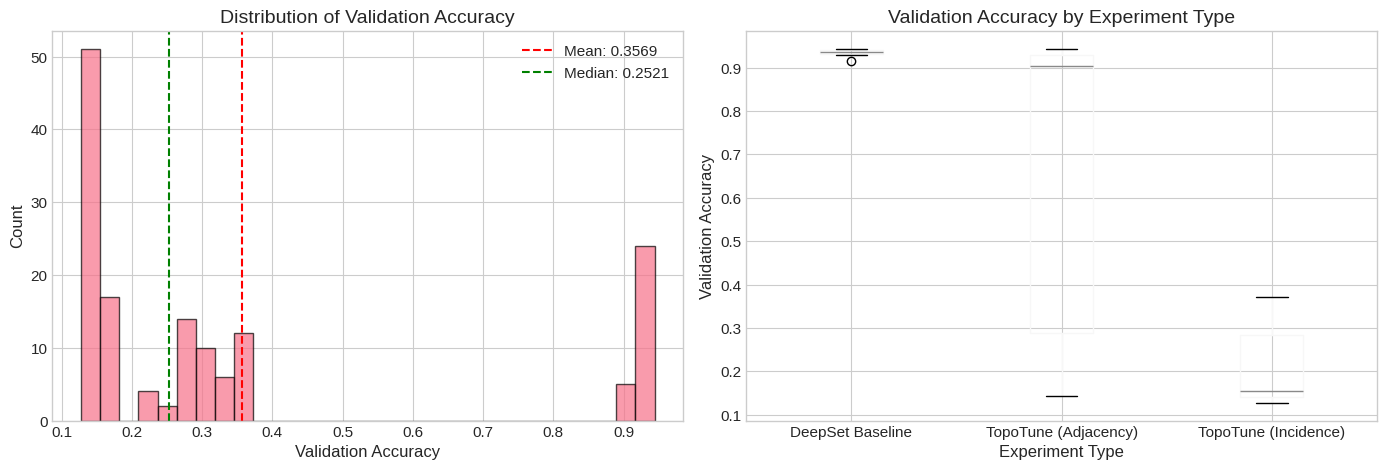

In [8]:
# Distribution of validation accuracy
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['val_accuracy'], bins=30, edgecolor='black', alpha=0.7)
axes[0].axvline(df['val_accuracy'].mean(), color='red', linestyle='--', label=f'Mean: {df["val_accuracy"].mean():.4f}')
axes[0].axvline(df['val_accuracy'].median(), color='green', linestyle='--', label=f'Median: {df["val_accuracy"].median():.4f}')
axes[0].set_xlabel('Validation Accuracy')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Validation Accuracy')
axes[0].legend()

# Box plot by experiment type
df.boxplot(column='val_accuracy', by='experiment_type', ax=axes[1])
axes[1].set_xlabel('Experiment Type')
axes[1].set_ylabel('Validation Accuracy')
axes[1].set_title('Validation Accuracy by Experiment Type')
plt.suptitle('')

plt.tight_layout()
plt.show()

## 4. Parameter Impact Analysis

### 4.1 Helper Function for Single Parameter Analysis

In [9]:
def analyze_parameter(df_agg, param_name, param_label, figsize=(14, 5)):
    """Comprehensive analysis of a single parameter's impact.
    
    Uses df_agg where each row is a configuration averaged over seeds.
    This ensures we're analyzing parameter effects, not seed variance.
    """
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    
    # Group statistics - now grouping configurations by parameter value
    grouped = df_agg.groupby(param_name)['val_accuracy'].agg(['mean', 'std', 'count', 'min', 'max'])
    print(f"\n{'='*60}")
    print(f"IMPACT OF {param_label.upper()}")
    print(f"(Each data point = 1 configuration, averaged over seeds)")
    print(f"{'='*60}")
    print(grouped.round(4))
    
    # Box plot
    df_agg.boxplot(column='val_accuracy', by=param_name, ax=axes[0])
    axes[0].set_xlabel(param_label)
    axes[0].set_ylabel('Validation Accuracy (mean over seeds)')
    axes[0].set_title(f'Distribution by {param_label}')
    
    # Bar plot with error bars
    means = grouped['mean']
    stds = grouped['std']
    x_pos = range(len(means))
    axes[1].bar(x_pos, means, yerr=stds, capsize=5, alpha=0.7, edgecolor='black')
    axes[1].set_xticks(x_pos)
    axes[1].set_xticklabels(means.index, rotation=45, ha='right')
    axes[1].set_xlabel(param_label)
    axes[1].set_ylabel('Mean Val Accuracy')
    axes[1].set_title(f'Mean ± Std by {param_label}')
    
    # Violin plot
    unique_vals = df_agg[param_name].unique()
    data_for_violin = [df_agg[df_agg[param_name] == v]['val_accuracy'].values for v in unique_vals]
    parts = axes[2].violinplot(data_for_violin, showmeans=True, showmedians=True)
    axes[2].set_xticks(range(1, len(unique_vals) + 1))
    axes[2].set_xticklabels(unique_vals, rotation=45, ha='right')
    axes[2].set_xlabel(param_label)
    axes[2].set_ylabel('Validation Accuracy')
    axes[2].set_title(f'Violin Plot by {param_label}')
    
    plt.suptitle('')
    plt.tight_layout()
    plt.show()
    
    # Statistical test
    unique_vals = df_agg[param_name].unique()
    if len(unique_vals) == 2:
        group1 = df_agg[df_agg[param_name] == unique_vals[0]]['val_accuracy']
        group2 = df_agg[df_agg[param_name] == unique_vals[1]]['val_accuracy']
        t_stat, p_value = stats.ttest_ind(group1, group2)
        print(f"\nT-test: t={t_stat:.4f}, p={p_value:.4f}")
        if p_value < 0.05:
            print(f"→ Statistically significant difference (p < 0.05)")
        else:
            print(f"→ No statistically significant difference (p >= 0.05)")
    elif len(unique_vals) > 2:
        groups = [df_agg[df_agg[param_name] == v]['val_accuracy'].values for v in unique_vals]
        f_stat, p_value = stats.f_oneway(*groups)
        print(f"\nANOVA: F={f_stat:.4f}, p={p_value:.4f}")
        if p_value < 0.05:
            print(f"→ Statistically significant difference between groups (p < 0.05)")
        else:
            print(f"→ No statistically significant difference (p >= 0.05)")
    
    return grouped

### 4.2 Impact of `ho_init_method` (Higher-Order Initialization)


IMPACT OF HO INIT METHOD
(Each data point = 1 configuration, averaged over seeds)
                  mean     std  count    min     max
ho_init_method                                      
avg_post        0.3780  0.3164     26  0.136  0.9358
bio             0.3381  0.2861     23  0.138  0.9341


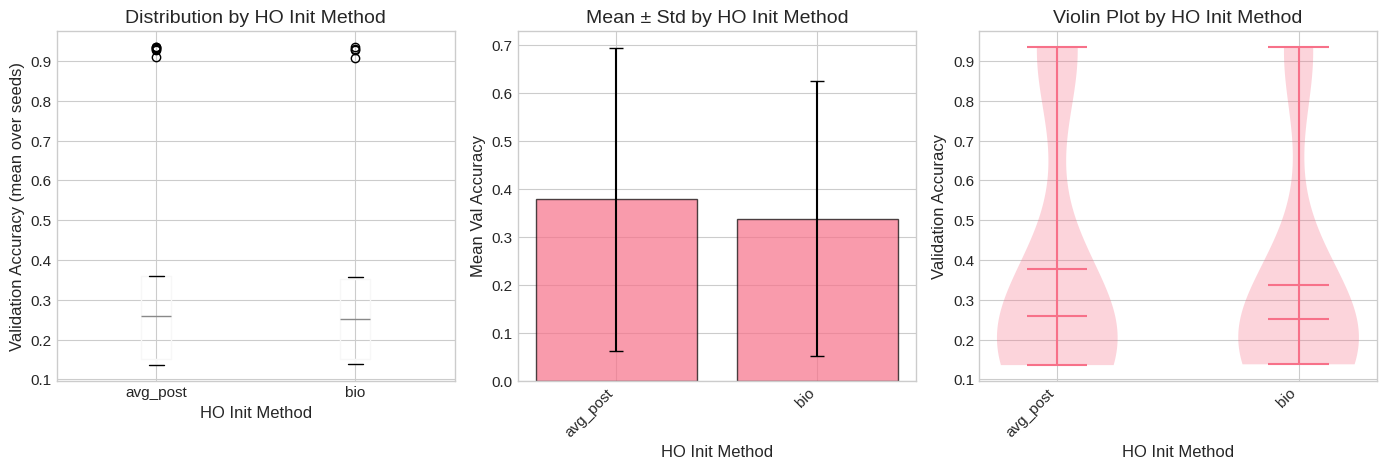


T-test: t=0.4603, p=0.6474
→ No statistically significant difference (p >= 0.05)


In [10]:
# Analyze ho_init_method (using df_agg - averaged over seeds)
ho_stats = analyze_parameter(df_agg, 'ho_init_method', 'HO Init Method')

### 4.3 Impact of `max_posts_per_user` (Data Filtering)


IMPACT OF MAX POSTS PER USER
(Each data point = 1 configuration, averaged over seeds)
                      mean     std  count     min     max
max_posts_per_user                                       
1000                0.3719  0.2930     25  0.1505  0.9341
2000                0.3461  0.3131     24  0.1360  0.9358


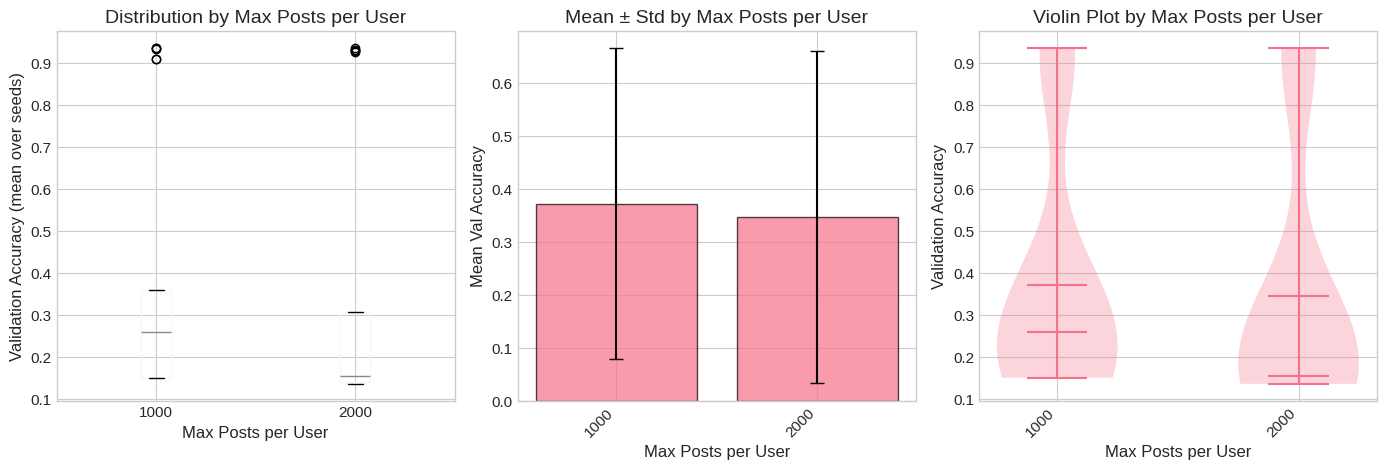


T-test: t=0.2978, p=0.7672
→ No statistically significant difference (p >= 0.05)


In [11]:
# Analyze max_posts_per_user (using df_agg - averaged over seeds)
posts_stats = analyze_parameter(df_agg, 'max_posts_per_user', 'Max Posts per User')

### 4.4 Impact of `neighborhood_label` (Topological Structure)


IMPACT OF NEIGHBORHOOD STRUCTURE
(Each data point = 1 configuration, averaged over seeds)
                          mean     std  count     min     max
neighborhood_label                                           
All Ranks (1,2,3)       0.4649  0.3443     12  0.1402  0.9283
No Topology (Baseline)  0.9341  0.0024      2  0.9325  0.9358
Rank-1 (User)           0.2637  0.0919     12  0.1380  0.3558
Rank-2 (Interaction)    0.4103  0.3858     12  0.1360  0.9341
Rank-3 (Community)      0.1882  0.0552     11  0.1380  0.2603


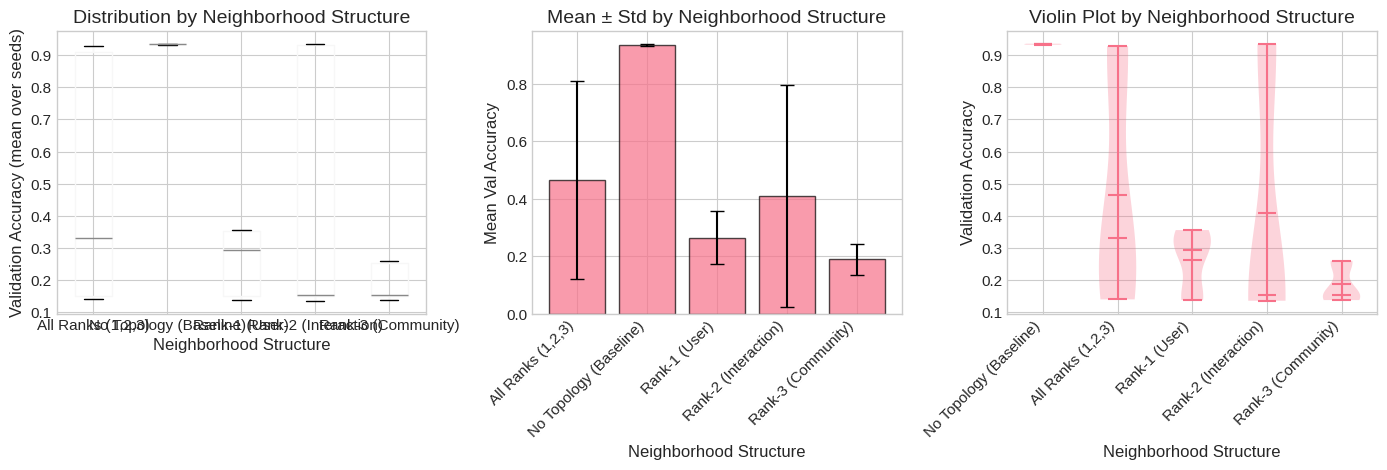


ANOVA: F=4.5138, p=0.0038
→ Statistically significant difference between groups (p < 0.05)


In [12]:
# Analyze neighborhood structure (using df_agg - averaged over seeds)
neigh_stats = analyze_parameter(df_agg, 'neighborhood_label', 'Neighborhood Structure')

### 4.5 Impact of `neighborhood_type` (Adjacency vs Incidence)


IMPACT OF NEIGHBORHOOD TYPE (ADJACENCY VS INCIDENCE)
(Each data point = 1 configuration, averaged over seeds)
                     mean     std  count     min     max
neighborhood_type                                       
adjacency          0.6248  0.3355     15  0.1578  0.9341
incidence          0.1989  0.0815     32  0.1360  0.3597


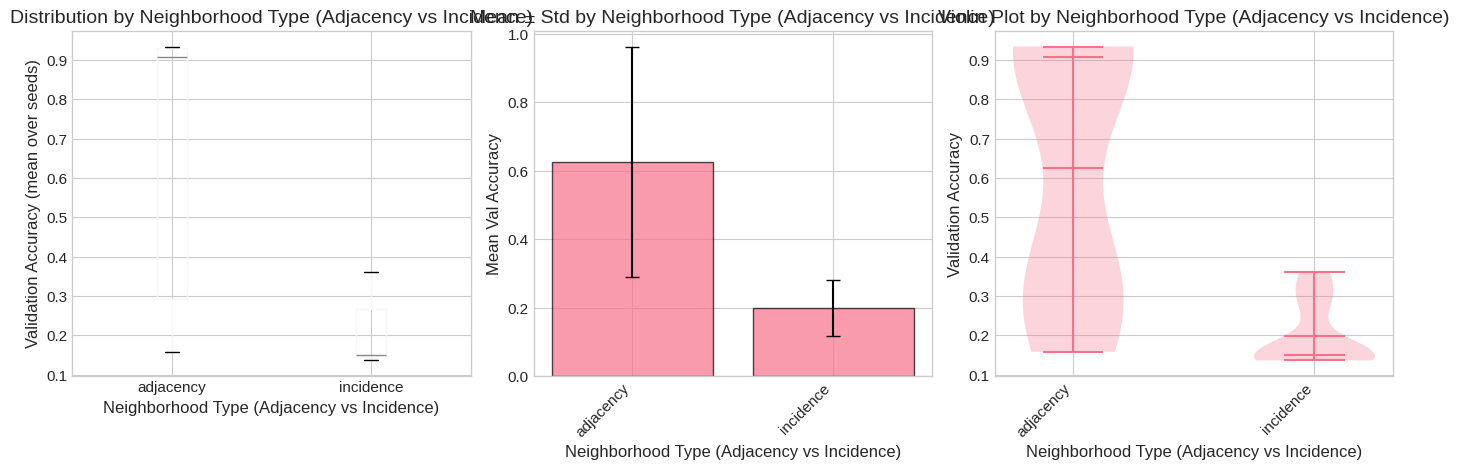


T-test: t=6.8403, p=0.0000
→ Statistically significant difference (p < 0.05)


In [13]:
# Filter out baseline for this comparison (using df_agg - averaged over seeds)
df_agg_topo = df_agg[df_agg['neighborhood_type'] != 'none']
if len(df_agg_topo) > 0:
    type_stats = analyze_parameter(df_agg_topo, 'neighborhood_type', 'Neighborhood Type (Adjacency vs Incidence)')

### 4.6 Impact of `ranks_to_propagate` (Signal Propagation)


IMPACT OF PROPAGATION STRATEGY
(Each data point = 1 configuration, averaged over seeds)
                     mean     std  count     min     max
propagation_label                                       
All Ranks (3,2,1)  0.3315  0.0310      4  0.3031  0.3597
No Propagation     0.4106  0.3512     33  0.1360  0.9358
Rank-1 Only        0.3240  0.0340      4  0.2945  0.3558
Rank-2 Only        0.1545  0.0055      4  0.1477  0.1604
Rank-3 Only        0.2036  0.0588      4  0.1528  0.2570


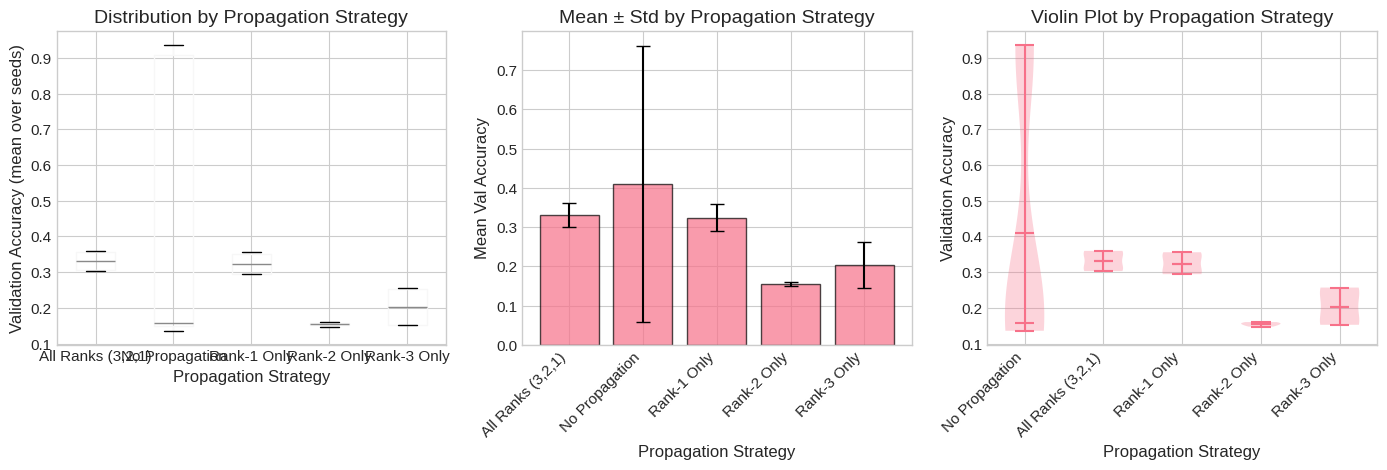


ANOVA: F=0.9982, p=0.4187
→ No statistically significant difference (p >= 0.05)


In [14]:
# Analyze propagation strategy (using df_agg - averaged over seeds)
prop_stats = analyze_parameter(df_agg, 'propagation_label', 'Propagation Strategy')

### 4.7 Seed Variance Check (Reproducibility)

This section verifies that results are stable across the 3 random seeds. We expect low variance - seeds are NOT a hyperparameter to optimize.

SEED VARIANCE CHECK (Reproducibility)

Configurations with multiple seeds: 49
Average std across seeds: 0.0123
Max std across seeds: 0.0271
Min std across seeds: 0.0040


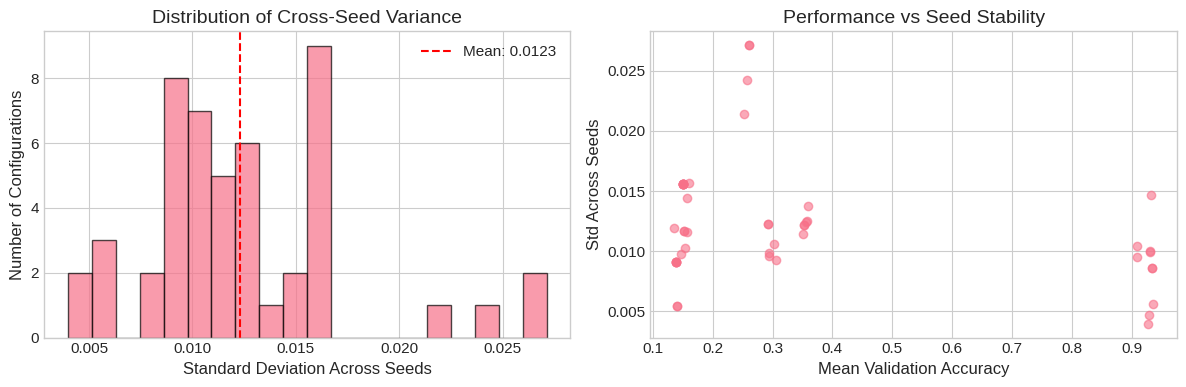


⚠️ High-variance configurations (top 10%):


,experiment_type,neighborhood_label,propagation_label,ho_init_method,max_posts_per_user,mean,std,count
14,TopoTune (Adjacency),Rank-3 (Community),No Propagation,avg_post,1000,0.260297,0.027120,3
16,TopoTune (Adjacency),Rank-3 (Community),No Propagation,bio,1000,0.260297,0.027120,3
37,TopoTune (Incidence),Rank-2 (Interaction),Rank-2 Only,avg_post,1000,0.160351,0.015658,3
45,TopoTune (Incidence),Rank-3 (Community),Rank-3 Only,avg_post,1000,0.257002,0.024268,3
47,TopoTune (Incidence),Rank-3 (Community),Rank-3 Only,bio,1000,0.252059,0.021417,3


In [15]:
# Check variance across seeds - this should be low for robust results
# Group by configuration (excluding seed) and compute std across seeds
config_cols_no_seed = ['experiment_type', 'neighborhood_label', 'propagation_label', 'ho_init_method', 'max_posts_per_user']

seed_variance = df.groupby(config_cols_no_seed)['val_accuracy'].agg(['mean', 'std', 'count']).reset_index()
seed_variance = seed_variance[seed_variance['count'] >= 2]  # Only configs with multiple seeds

print("="*60)
print("SEED VARIANCE CHECK (Reproducibility)")
print("="*60)
print(f"\nConfigurations with multiple seeds: {len(seed_variance)}")
print(f"Average std across seeds: {seed_variance['std'].mean():.4f}")
print(f"Max std across seeds: {seed_variance['std'].max():.4f}")
print(f"Min std across seeds: {seed_variance['std'].min():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram of std values
axes[0].hist(seed_variance['std'].dropna(), bins=20, edgecolor='black', alpha=0.7)
axes[0].axvline(seed_variance['std'].mean(), color='red', linestyle='--', 
                label=f'Mean: {seed_variance["std"].mean():.4f}')
axes[0].set_xlabel('Standard Deviation Across Seeds')
axes[0].set_ylabel('Number of Configurations')
axes[0].set_title('Distribution of Cross-Seed Variance')
axes[0].legend()

# Scatter: mean vs std
axes[1].scatter(seed_variance['mean'], seed_variance['std'], alpha=0.6)
axes[1].set_xlabel('Mean Validation Accuracy')
axes[1].set_ylabel('Std Across Seeds')
axes[1].set_title('Performance vs Seed Stability')

plt.tight_layout()
plt.show()

# Flag high-variance configurations
high_var = seed_variance[seed_variance['std'] > seed_variance['std'].quantile(0.9)]
if len(high_var) > 0:
    print(f"\n⚠️ High-variance configurations (top 10%):")
    display(high_var)

## 5. Interaction Effects Analysis

### 5.1 Helper Function for Interaction Analysis

In [16]:
def analyze_interaction(df_agg, param1, param2, label1, label2, figsize=(14, 6)):
    """Analyze interaction between two parameters.
    
    Uses df_agg where each row is a configuration averaged over seeds.
    """
    # Pivot table
    pivot_mean = df_agg.pivot_table(values='val_accuracy', index=param1, columns=param2, aggfunc='mean')
    pivot_std = df_agg.pivot_table(values='val_accuracy', index=param1, columns=param2, aggfunc='std')
    pivot_count = df_agg.pivot_table(values='val_accuracy', index=param1, columns=param2, aggfunc='count')
    
    print(f"\n{'='*60}")
    print(f"INTERACTION: {label1.upper()} × {label2.upper()}")
    print(f"(Each cell = mean of configurations with those param values)")
    print(f"{'='*60}")
    print("\nMean Validation Accuracy:")
    print(pivot_mean.round(4))
    print("\nStandard Deviation (across configurations):")
    print(pivot_std.round(4))
    print("\nNumber of Configurations:")
    print(pivot_count)
    
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    # Heatmap
    sns.heatmap(pivot_mean, annot=True, fmt='.4f', cmap='RdYlGn', ax=axes[0],
                cbar_kws={'label': 'Val Accuracy'})
    axes[0].set_title(f'Mean Val Accuracy: {label1} × {label2}')
    axes[0].set_xlabel(label2)
    axes[0].set_ylabel(label1)
    
    # Grouped bar chart
    pivot_mean.plot(kind='bar', ax=axes[1], yerr=pivot_std, capsize=3)
    axes[1].set_xlabel(label1)
    axes[1].set_ylabel('Mean Validation Accuracy')
    axes[1].set_title(f'{label1} × {label2} Interaction')
    axes[1].legend(title=label2)
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    return pivot_mean

### 5.2 ho_init_method × max_posts_per_user


INTERACTION: HO INIT METHOD × MAX POSTS/USER
(Each cell = mean of configurations with those param values)

Mean Validation Accuracy:
max_posts_per_user    1000    2000
ho_init_method                    
avg_post            0.3941  0.3619
bio                 0.3479  0.3275

Standard Deviation (across configurations):
max_posts_per_user    1000    2000
ho_init_method                    
avg_post            0.3135  0.3312
bio                 0.2807  0.3053

Number of Configurations:
max_posts_per_user  1000  2000
ho_init_method                
avg_post              13    13
bio                   12    11


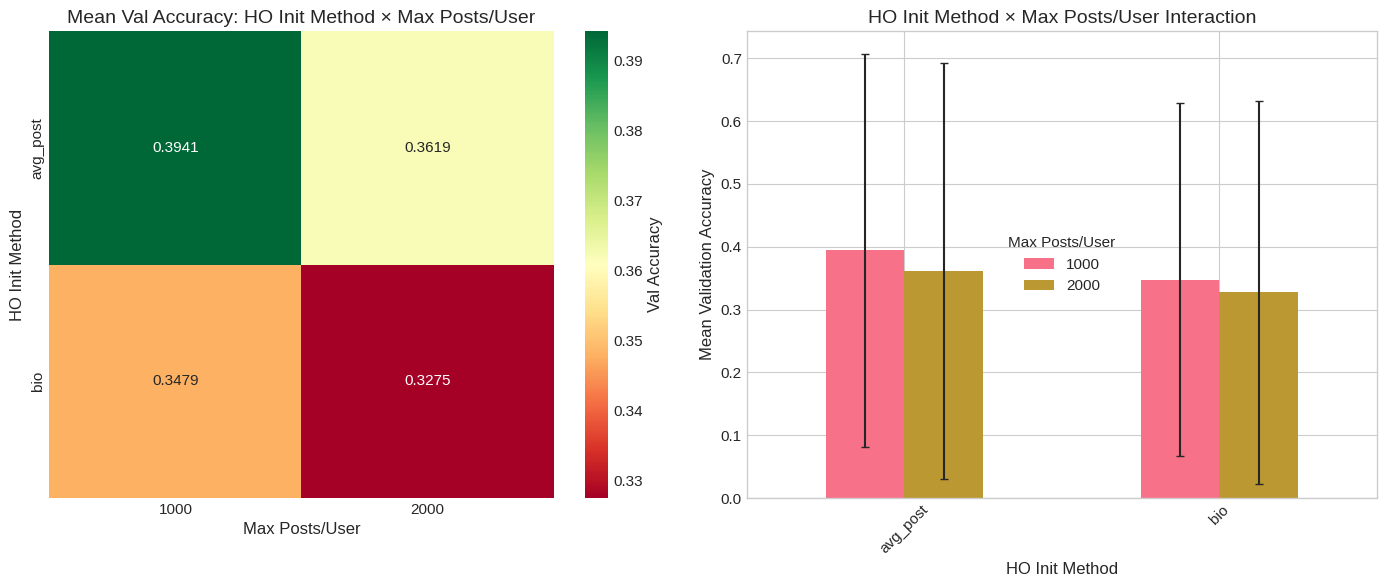

In [17]:
# ho_init_method × max_posts_per_user (using df_agg)
interact1 = analyze_interaction(df_agg, 'ho_init_method', 'max_posts_per_user', 
                                 'HO Init Method', 'Max Posts/User')

### 5.3 neighborhood_label × ho_init_method


INTERACTION: NEIGHBORHOOD × HO INIT METHOD
(Each cell = mean of configurations with those param values)

Mean Validation Accuracy:
ho_init_method          avg_post     bio
neighborhood_label                      
All Ranks (1,2,3)         0.4656  0.4643
No Topology (Baseline)    0.9341     NaN
Rank-1 (User)             0.2641  0.2632
Rank-2 (Interaction)      0.4109  0.4098
Rank-3 (Community)        0.1861  0.1907

Standard Deviation (across configurations):
ho_init_method          avg_post     bio
neighborhood_label                      
All Ranks (1,2,3)         0.3612  0.3611
No Topology (Baseline)    0.0024     NaN
Rank-1 (User)             0.0968  0.0959
Rank-2 (Interaction)      0.4043  0.4051
Rank-3 (Community)        0.0566  0.0601

Number of Configurations:
ho_init_method          avg_post  bio
neighborhood_label                   
All Ranks (1,2,3)            6.0  6.0
No Topology (Baseline)       2.0  NaN
Rank-1 (User)                6.0  6.0
Rank-2 (Interaction)         6.0

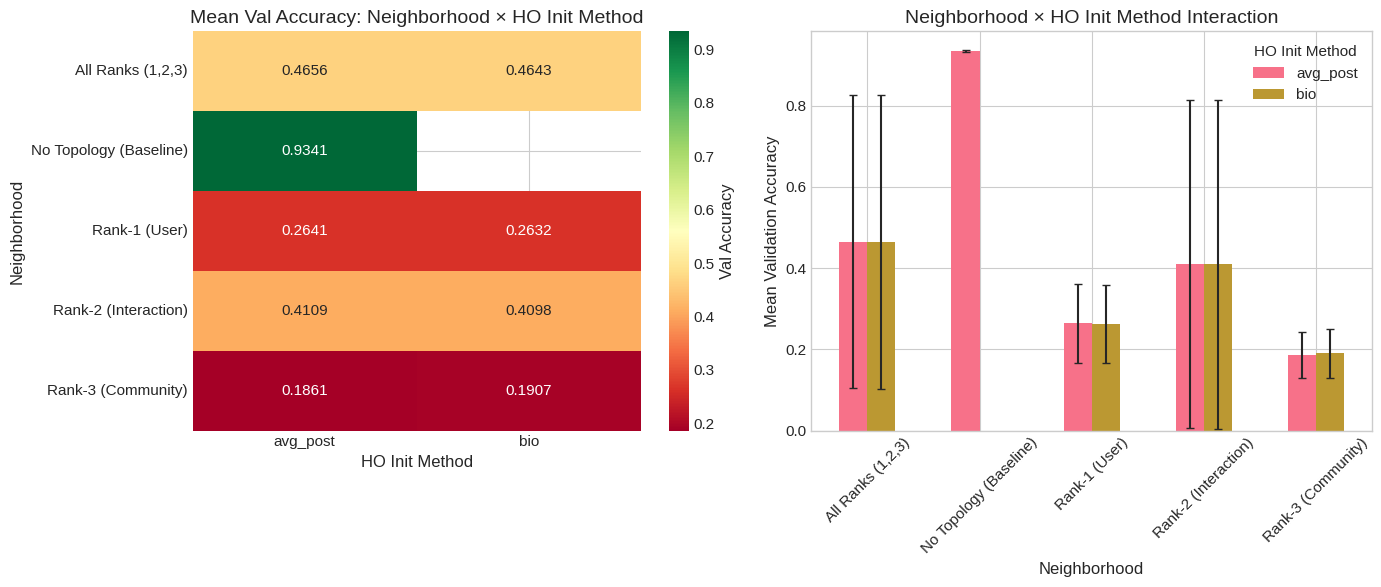

In [18]:
# neighborhood × ho_init_method (using df_agg)
interact2 = analyze_interaction(df_agg, 'neighborhood_label', 'ho_init_method',
                                 'Neighborhood', 'HO Init Method')

### 5.4 neighborhood_label × propagation_label


INTERACTION: NEIGHBORHOOD × PROPAGATION
(Each cell = mean of configurations with those param values)

Mean Validation Accuracy:
propagation_label       All Ranks (3,2,1)  No Propagation  Rank-1 Only  \
neighborhood_label                                                       
All Ranks (1,2,3)                  0.3315          0.5317          NaN   
No Topology (Baseline)                NaN          0.9341          NaN   
Rank-1 (User)                         NaN          0.2335        0.324   
Rank-2 (Interaction)                  NaN          0.5382          NaN   
Rank-3 (Community)                    NaN          0.1793          NaN   

propagation_label       Rank-2 Only  Rank-3 Only  
neighborhood_label                                
All Ranks (1,2,3)               NaN          NaN  
No Topology (Baseline)          NaN          NaN  
Rank-1 (User)                   NaN          NaN  
Rank-2 (Interaction)         0.1545          NaN  
Rank-3 (Community)              NaN       0.20

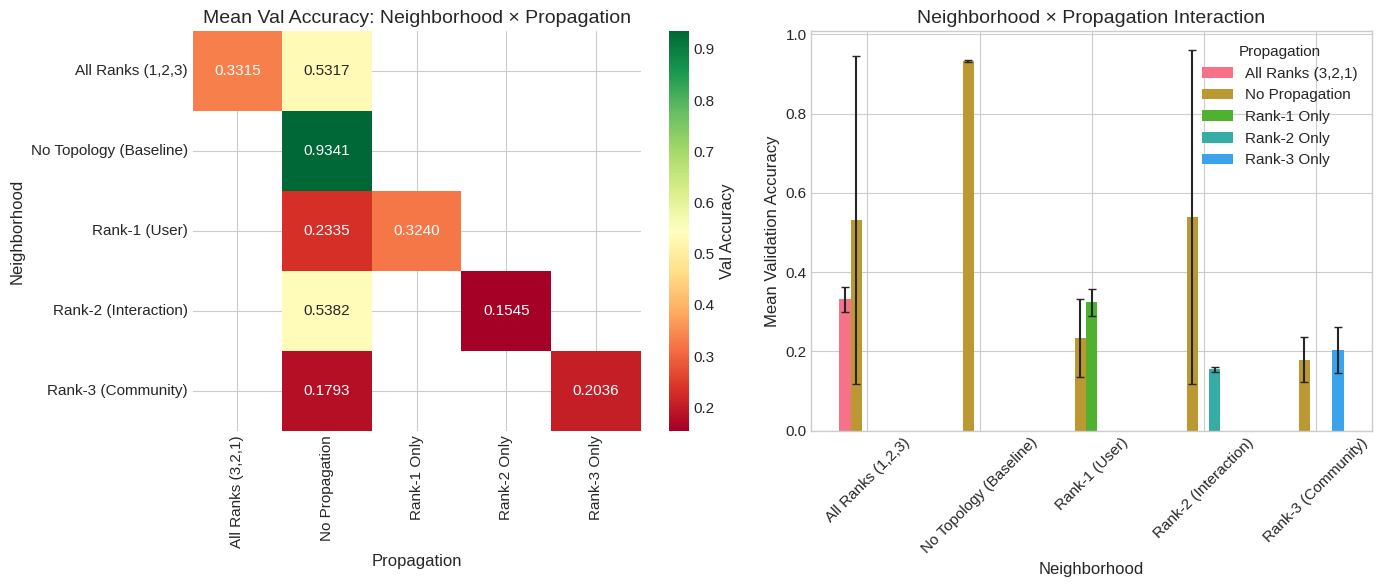

In [19]:
# neighborhood × propagation (using df_agg)
interact3 = analyze_interaction(df_agg, 'neighborhood_label', 'propagation_label',
                                 'Neighborhood', 'Propagation')

### 5.5 neighborhood_type × propagation_label (TopoTune Only)


INTERACTION: NEIGHBORHOOD TYPE × PROPAGATION
(Each cell = mean of configurations with those param values)

Mean Validation Accuracy:
propagation_label  All Ranks (3,2,1)  No Propagation  Rank-1 Only  \
neighborhood_type                                                   
adjacency                        NaN          0.6248          NaN   
incidence                     0.3315          0.1444        0.324   

propagation_label  Rank-2 Only  Rank-3 Only  
neighborhood_type                            
adjacency                  NaN          NaN  
incidence               0.1545       0.2036  

Standard Deviation (across configurations):
propagation_label  All Ranks (3,2,1)  No Propagation  Rank-1 Only  \
neighborhood_type                                                   
adjacency                        NaN          0.3355          NaN   
incidence                      0.031          0.0063        0.034   

propagation_label  Rank-2 Only  Rank-3 Only  
neighborhood_type                    

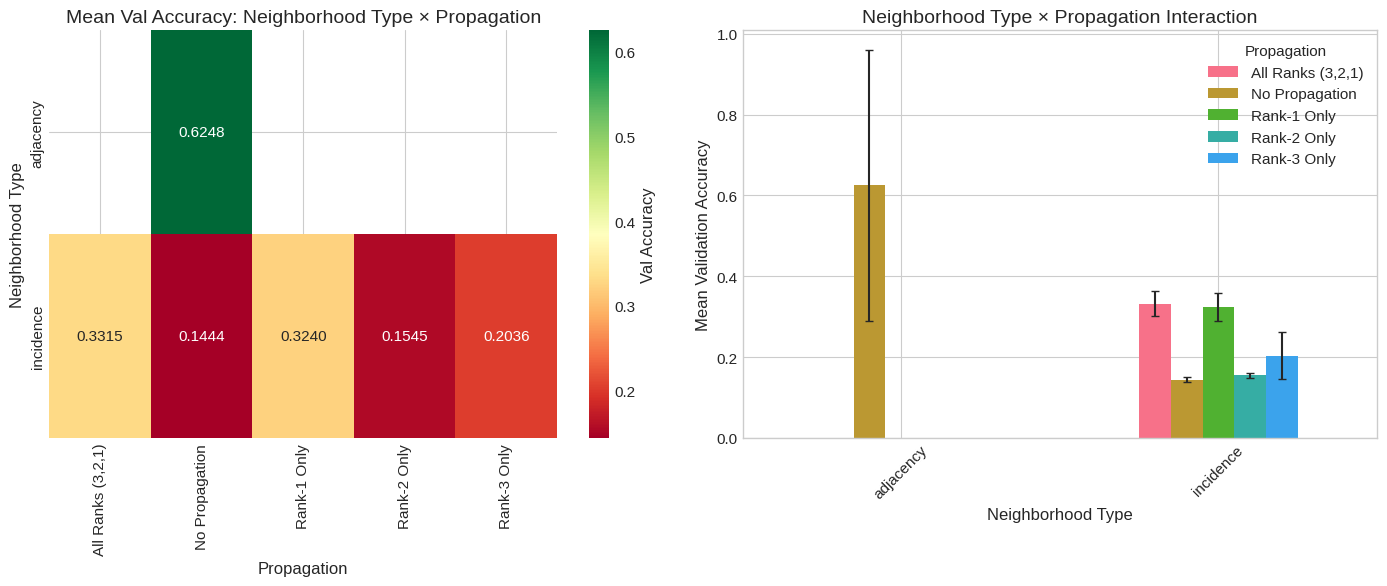

In [20]:
df_agg_topo = df_agg[df_agg['neighborhood_type'].isin(['adjacency', 'incidence'])]
if len(df_agg_topo) > 0:
    interact4 = analyze_interaction(df_agg_topo, 'neighborhood_type', 'propagation_label',
                                     'Neighborhood Type', 'Propagation')

## 6. Detailed Neighborhood Analysis

### 6.1 Adjacency vs Incidence per Rank


Performance by Rank and Neighborhood Type (config-level means):
                                       mean     std  count
neighborhood_rank neighborhood_type                       
1                 adjacency          0.3228  0.0350      4
                  incidence          0.2341  0.0987      8
2                 adjacency          0.9327  0.0016      4
                  incidence          0.1491  0.0085      8
3                 adjacency          0.2261  0.0592      3
                  incidence          0.1739  0.0501      8
all               adjacency          0.9180  0.0109      4
                  incidence          0.2384  0.1016      8


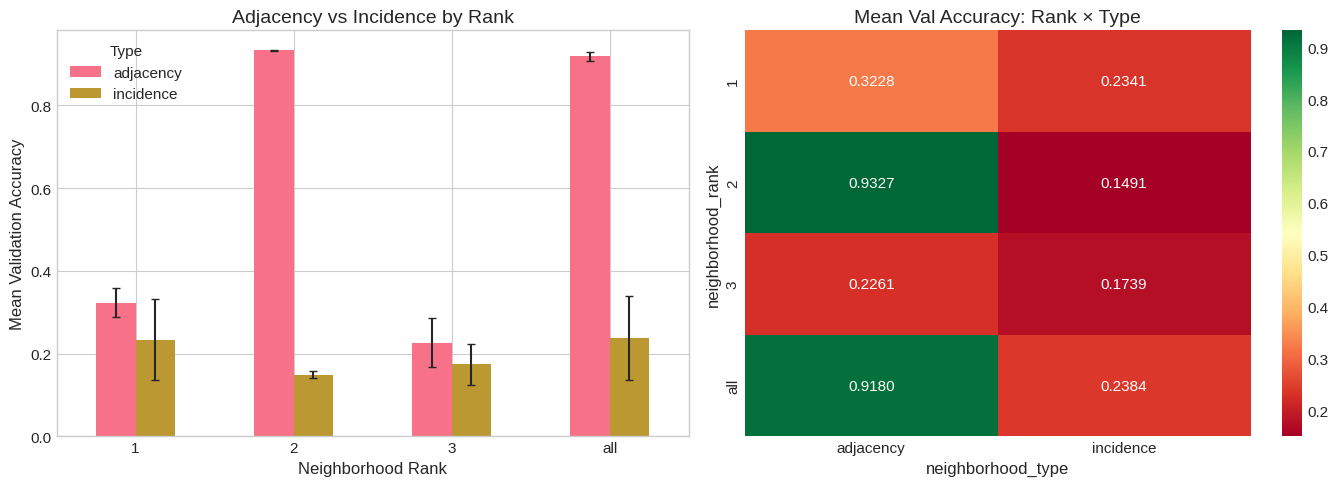

In [21]:
# Compare adjacency vs incidence for each rank (using df_agg)
df_agg_topo = df_agg[df_agg['neighborhood_type'].isin(['adjacency', 'incidence'])]

if len(df_agg_topo) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Group by rank and type
    rank_type_stats = df_agg_topo.groupby(['neighborhood_rank', 'neighborhood_type'])['val_accuracy'].agg(['mean', 'std', 'count'])
    print("\nPerformance by Rank and Neighborhood Type (config-level means):")
    print(rank_type_stats.round(4))
    
    # Pivot for visualization
    pivot = df_agg_topo.pivot_table(values='val_accuracy', index='neighborhood_rank', 
                                 columns='neighborhood_type', aggfunc='mean')
    pivot_std = df_agg_topo.pivot_table(values='val_accuracy', index='neighborhood_rank', 
                                     columns='neighborhood_type', aggfunc='std')
    
    # Bar plot
    pivot.plot(kind='bar', ax=axes[0], yerr=pivot_std, capsize=3)
    axes[0].set_xlabel('Neighborhood Rank')
    axes[0].set_ylabel('Mean Validation Accuracy')
    axes[0].set_title('Adjacency vs Incidence by Rank')
    axes[0].legend(title='Type')
    axes[0].tick_params(axis='x', rotation=0)
    
    # Heatmap
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='RdYlGn', ax=axes[1])
    axes[1].set_title('Mean Val Accuracy: Rank × Type')
    
    plt.tight_layout()
    plt.show()

### 6.2 Single Rank vs All Ranks


Single Rank vs All Ranks (config-level means):
               mean     std  count
Single Rank  0.2902  0.2460     35
All Ranks    0.4649  0.3443     12


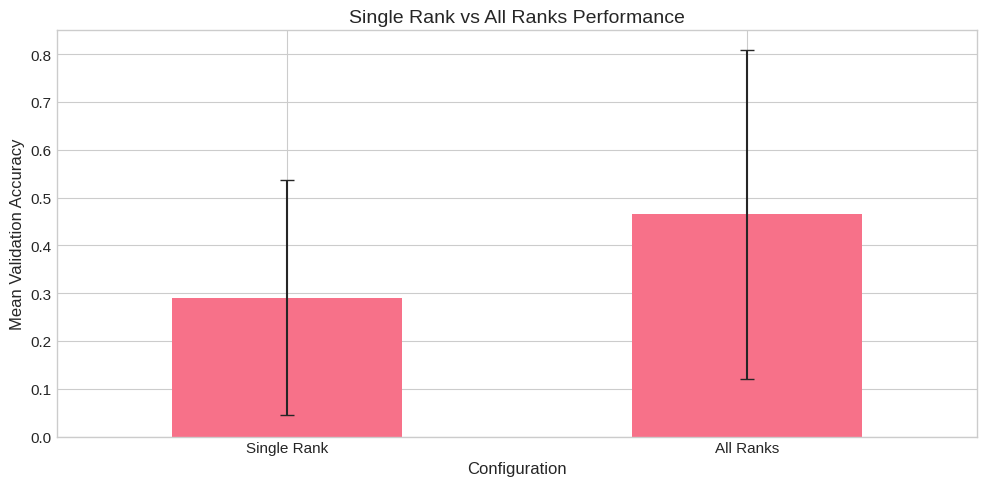


T-test (Single vs All): t=-1.9110, p=0.0624


In [22]:
# Compare single rank vs all ranks (using df_agg)
df_agg['is_all_ranks'] = df_agg['neighborhood_rank'] == 'all'
df_agg_topo = df_agg[df_agg['neighborhood_type'] != 'none']

if len(df_agg_topo) > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    
    single_vs_all = df_agg_topo.groupby('is_all_ranks')['val_accuracy'].agg(['mean', 'std', 'count'])
    single_vs_all.index = ['Single Rank', 'All Ranks']
    print("\nSingle Rank vs All Ranks (config-level means):")
    print(single_vs_all.round(4))
    
    single_vs_all['mean'].plot(kind='bar', yerr=single_vs_all['std'], capsize=5, ax=ax)
    ax.set_xlabel('Configuration')
    ax.set_ylabel('Mean Validation Accuracy')
    ax.set_title('Single Rank vs All Ranks Performance')
    ax.tick_params(axis='x', rotation=0)
    
    plt.tight_layout()
    plt.show()
    
    # T-test
    single = df_agg_topo[~df_agg_topo['is_all_ranks']]['val_accuracy']
    all_ranks = df_agg_topo[df_agg_topo['is_all_ranks']]['val_accuracy']
    if len(single) > 0 and len(all_ranks) > 0:
        t_stat, p_value = stats.ttest_ind(single, all_ranks)
        print(f"\nT-test (Single vs All): t={t_stat:.4f}, p={p_value:.4f}")

## 7. Baseline Comparison (TopoTune vs DeepSet)

DeepSet Baseline configurations: 2
TopoTune configurations: 47

DeepSet Baseline: 0.9341 ± 0.0024
TopoTune (all configs): 0.3348 ± 0.2811
Improvement: -59.93 percentage points


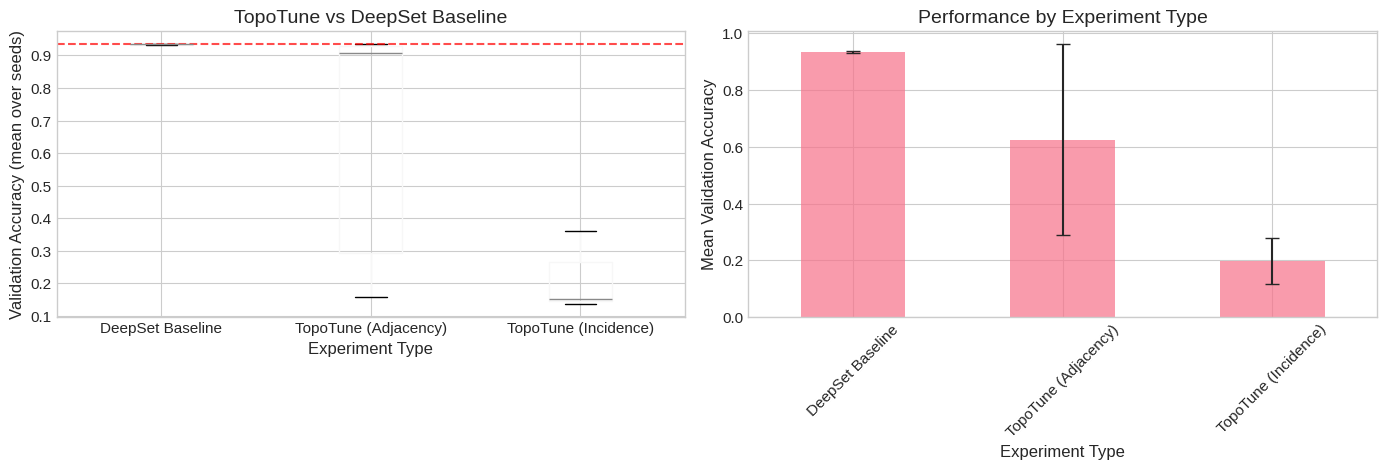


T-test (Baseline vs TopoTune): t=2.9850, p=0.0045


In [23]:
# Separate baseline and TopoTune results (using df_agg - config-level means)
df_agg_baseline = df_agg[df_agg['experiment_type'] == 'DeepSet Baseline']
df_agg_topotune = df_agg[df_agg['experiment_type'] != 'DeepSet Baseline']

print(f"DeepSet Baseline configurations: {len(df_agg_baseline)}")
print(f"TopoTune configurations: {len(df_agg_topotune)}")

if len(df_agg_baseline) > 0 and len(df_agg_topotune) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Statistics (already averaged over seeds)
    baseline_mean = df_agg_baseline['val_accuracy'].mean()
    baseline_std = df_agg_baseline['val_accuracy'].std()
    topotune_mean = df_agg_topotune['val_accuracy'].mean()
    topotune_std = df_agg_topotune['val_accuracy'].std()
    
    print(f"\nDeepSet Baseline: {baseline_mean:.4f} ± {baseline_std:.4f}")
    print(f"TopoTune (all configs): {topotune_mean:.4f} ± {topotune_std:.4f}")
    print(f"Improvement: {(topotune_mean - baseline_mean) * 100:.2f} percentage points")
    
    # Box plot comparison
    df_agg.boxplot(column='val_accuracy', by='experiment_type', ax=axes[0])
    axes[0].axhline(baseline_mean, color='red', linestyle='--', alpha=0.7, label='Baseline Mean')
    axes[0].set_xlabel('Experiment Type')
    axes[0].set_ylabel('Validation Accuracy (mean over seeds)')
    axes[0].set_title('TopoTune vs DeepSet Baseline')
    plt.suptitle('')
    
    # Detailed comparison by experiment type
    type_stats = df_agg.groupby('experiment_type')['val_accuracy'].agg(['mean', 'std', 'count'])
    type_stats['mean'].plot(kind='bar', yerr=type_stats['std'], capsize=5, ax=axes[1], alpha=0.7)
    axes[1].set_xlabel('Experiment Type')
    axes[1].set_ylabel('Mean Validation Accuracy')
    axes[1].set_title('Performance by Experiment Type')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # T-test on configuration-level means
    t_stat, p_value = stats.ttest_ind(df_agg_baseline['val_accuracy'], df_agg_topotune['val_accuracy'])
    print(f"\nT-test (Baseline vs TopoTune): t={t_stat:.4f}, p={p_value:.4f}")

## 8. Top Configurations Leaderboard

In [24]:
# Top 10 individual runs (showing raw df to see seed-level results)
top_runs = df.nlargest(10, 'val_accuracy')[[
    'val_accuracy', 'test_accuracy', 'experiment_type', 'neighborhood_label',
    'propagation_label', 'ho_init_method', 'max_posts_per_user', 'data_seed'
]]

print("="*80)
print("TOP 10 INDIVIDUAL RUNS (seed-level)")
print("="*80)
print("Note: These are individual runs before averaging over seeds")
display(top_runs)

TOP 10 INDIVIDUAL RUNS (seed-level)
Note: These are individual runs before averaging over seeds


,val_accuracy,test_accuracy,experiment_type,neighborhood_label,propagation_label,ho_init_method,max_posts_per_user,data_seed
18,0.943987,0.899671,TopoTune (Adjacency),Rank-2 (Interaction),No Propagation,avg_post,1000,3
20,0.943987,0.899671,TopoTune (Adjacency),Rank-2 (Interaction),No Propagation,bio,1000,3
142,0.943987,0.935855,DeepSet Baseline,No Topology (Baseline),No Propagation,avg_post,1000,1
139,0.941413,0.928629,DeepSet Baseline,No Topology (Baseline),No Propagation,avg_post,2000,3
22,0.938202,0.923817,TopoTune (Adjacency),Rank-2 (Interaction),No Propagation,bio,2000,3
19,0.937400,0.926223,TopoTune (Adjacency),Rank-2 (Interaction),No Propagation,avg_post,2000,3
141,0.937397,0.906250,DeepSet Baseline,No Topology (Baseline),No Propagation,avg_post,1000,3
4,0.936597,0.923817,TopoTune (Adjacency),Rank-2 (Interaction),No Propagation,avg_post,2000,1
7,0.935795,0.923817,TopoTune (Adjacency),Rank-2 (Interaction),No Propagation,bio,2000,1
143,0.935795,0.938252,DeepSet Baseline,No Topology (Baseline),No Propagation,avg_post,2000,5


In [25]:
# Top configurations (already aggregated in df_agg)
print("\n" + "="*80)
print("TOP 10 CONFIGURATIONS (AVERAGED ACROSS SEEDS)")
print("="*80)
print("This is the definitive ranking - each row represents a unique configuration with mean±std over 3 seeds\n")

top_configs = df_agg.nlargest(10, 'val_accuracy')[
    ['experiment_type', 'neighborhood_label', 'propagation_label', 
     'ho_init_method', 'max_posts_per_user', 'val_accuracy', 'val_std', 'n_seeds']
]
display(top_configs)


TOP 10 CONFIGURATIONS (AVERAGED ACROSS SEEDS)
This is the definitive ranking - each row represents a unique configuration with mean±std over 3 seeds



,experiment_type,neighborhood_label,propagation_label,ho_init_method,max_posts_per_user,val_accuracy,val_std,n_seeds
1,DeepSet Baseline,No Topology (Baseline),No Propagation,avg_post,2000,0.935795,0.005618,3
10,TopoTune (Adjacency),Rank-2 (Interaction),No Propagation,avg_post,1000,0.934102,0.008560,3
12,TopoTune (Adjacency),Rank-2 (Interaction),No Propagation,bio,1000,0.934102,0.008560,3
0,DeepSet Baseline,No Topology (Baseline),No Propagation,avg_post,1000,0.932455,0.014643,3
11,TopoTune (Adjacency),Rank-2 (Interaction),No Propagation,avg_post,2000,0.931247,0.009970,3
13,TopoTune (Adjacency),Rank-2 (Interaction),No Propagation,bio,2000,0.931247,0.010035,3
3,TopoTune (Adjacency),"All Ranks (1,2,3)",No Propagation,avg_post,2000,0.928304,0.004703,3
5,TopoTune (Adjacency),"All Ranks (1,2,3)",No Propagation,bio,2000,0.926565,0.003973,2
2,TopoTune (Adjacency),"All Ranks (1,2,3)",No Propagation,avg_post,1000,0.908841,0.010463,3
4,TopoTune (Adjacency),"All Ranks (1,2,3)",No Propagation,bio,1000,0.908292,0.009512,3


## 9. Variance Analysis (Stability)

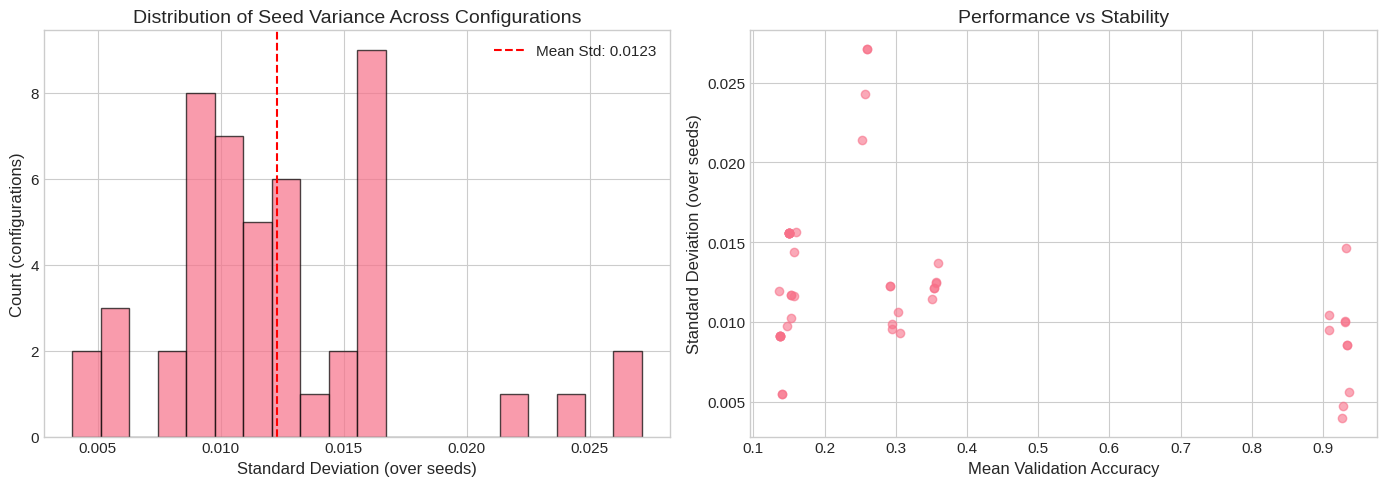


Most Stable Configurations (Low Std, High Accuracy):


,experiment_type,neighborhood_label,propagation_label,ho_init_method,max_posts_per_user,val_accuracy,val_std
5,TopoTune (Adjacency),"All Ranks (1,2,3)",No Propagation,bio,2000,0.926565,0.003973
3,TopoTune (Adjacency),"All Ranks (1,2,3)",No Propagation,avg_post,2000,0.928304,0.004703
22,TopoTune (Incidence),"All Ranks (1,2,3)",No Propagation,avg_post,2000,0.140182,0.005463
24,TopoTune (Incidence),"All Ranks (1,2,3)",No Propagation,bio,2000,0.140182,0.005463
1,DeepSet Baseline,No Topology (Baseline),No Propagation,avg_post,2000,0.935795,0.005618
10,TopoTune (Adjacency),Rank-2 (Interaction),No Propagation,avg_post,1000,0.934102,0.008560
12,TopoTune (Adjacency),Rank-2 (Interaction),No Propagation,bio,1000,0.934102,0.008560
36,TopoTune (Incidence),Rank-2 (Interaction),No Propagation,bio,2000,0.138042,0.009115
44,TopoTune (Incidence),Rank-3 (Community),No Propagation,bio,2000,0.138042,0.009115
26,TopoTune (Incidence),Rank-1 (User),No Propagation,avg_post,2000,0.138042,0.009115


In [26]:
# Analyze variance across seeds for each configuration (using df_agg)
# df_agg already has val_std computed from the 3 seeds

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Filter to configs with complete seed runs
df_agg_complete = df_agg[df_agg['n_seeds'] >= 2].copy()

# Std distribution
axes[0].hist(df_agg_complete['val_std'].dropna(), bins=20, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Standard Deviation (over seeds)')
axes[0].set_ylabel('Count (configurations)')
axes[0].set_title('Distribution of Seed Variance Across Configurations')
mean_std = df_agg_complete['val_std'].mean()
axes[0].axvline(mean_std, color='red', linestyle='--', 
                label=f'Mean Std: {mean_std:.4f}')
axes[0].legend()

# Mean vs Std scatter (higher accuracy vs stability tradeoff?)
axes[1].scatter(df_agg_complete['val_accuracy'], df_agg_complete['val_std'], alpha=0.6)
axes[1].set_xlabel('Mean Validation Accuracy')
axes[1].set_ylabel('Standard Deviation (over seeds)')
axes[1].set_title('Performance vs Stability')

plt.tight_layout()
plt.show()

# Most stable configurations (low std, high mean)
stable_configs = df_agg_complete.sort_values(['val_std', 'val_accuracy'], ascending=[True, False]).head(10)
print("\nMost Stable Configurations (Low Std, High Accuracy):")
display(stable_configs[['experiment_type', 'neighborhood_label', 'propagation_label', 
                        'ho_init_method', 'max_posts_per_user', 'val_accuracy', 'val_std']])

print("="*80)
print("SUMMARY OF FINDINGS")
print("="*80)

# Best values for each parameter (using df_agg - properly aggregated over seeds)
params_to_analyze = [
    ('ho_init_method', 'HO Init Method'),
    ('max_posts_per_user', 'Max Posts/User'),
    ('neighborhood_label', 'Neighborhood'),
    ('propagation_label', 'Propagation'),
]

print("\nBest Value for Each Parameter (by mean val accuracy, aggregated over seeds):")
print("-" * 60)
for param, label in params_to_analyze:
    grouped = df_agg.groupby(param)['val_accuracy'].mean()
    best = grouped.idxmax()
    best_val = grouped.max()
    print(f"{label:25s}: {best} ({best_val:.4f})")

# Overall best configuration (from df_agg which is properly aggregated)
print("\n" + "-" * 60)
print("\nRECOMMENDED CONFIGURATION (best mean accuracy over seeds):")
best_config = df_agg.loc[df_agg['val_accuracy'].idxmax()]
print(f"  Experiment Type: {best_config['experiment_type']}")
print(f"  Neighborhood: {best_config['neighborhood_label']}")
print(f"  Propagation: {best_config['propagation_label']}")
print(f"  HO Init Method: {best_config['ho_init_method']}")
print(f"  Max Posts/User: {best_config['max_posts_per_user']}")
print(f"  Mean Val Accuracy: {best_config['val_accuracy']:.4f} ± {best_config['val_std']:.4f}")
print(f"  Number of seeds: {best_config['n_seeds']}")

In [27]:
print("="*80)
print("SUMMARY OF FINDINGS")
print("="*80)

# Best values for each parameter (using df_agg - properly aggregated over seeds)
params_to_analyze = [
    ('ho_init_method', 'HO Init Method'),
    ('max_posts_per_user', 'Max Posts/User'),
    ('neighborhood_label', 'Neighborhood'),
    ('propagation_label', 'Propagation'),
]

print("\nBest Value for Each Parameter (by mean val accuracy, aggregated over seeds):")
print("-" * 60)
for param, label in params_to_analyze:
    grouped = df_agg.groupby(param)['val_accuracy'].mean()
    best = grouped.idxmax()
    best_val = grouped.max()
    print(f"{label:25s}: {best} ({best_val:.4f})")

# Overall best configuration (from df_agg which is properly aggregated)
print("\n" + "-" * 60)
print("\nRECOMMENDED CONFIGURATION (best mean accuracy over seeds):")
best_config = df_agg.loc[df_agg['val_accuracy'].idxmax()]
print(f"  Experiment Type: {best_config['experiment_type']}")
print(f"  Neighborhood: {best_config['neighborhood_label']}")
print(f"  Propagation: {best_config['propagation_label']}")
print(f"  HO Init Method: {best_config['ho_init_method']}")
print(f"  Max Posts/User: {best_config['max_posts_per_user']}")
print(f"  Mean Val Accuracy: {best_config['val_accuracy']:.4f} ± {best_config['val_std']:.4f}")
print(f"  Number of seeds: {best_config['n_seeds']}")

SUMMARY OF FINDINGS

Best Value for Each Parameter (by mean val accuracy, aggregated over seeds):
------------------------------------------------------------
HO Init Method           : avg_post (0.3780)
Max Posts/User           : 1000 (0.3719)
Neighborhood             : No Topology (Baseline) (0.9341)
Propagation              : No Propagation (0.4106)

------------------------------------------------------------

RECOMMENDED CONFIGURATION (best mean accuracy over seeds):
  Experiment Type: DeepSet Baseline
  Neighborhood: No Topology (Baseline)
  Propagation: No Propagation
  HO Init Method: avg_post
  Max Posts/User: 2000
  Mean Val Accuracy: 0.9358 ± 0.0056
  Number of seeds: 3


## 11. Export Results

In [28]:
# Export full results to CSV
df.to_csv('maga_experiment_results_all_runs.csv', index=False)
df_agg.to_csv('maga_experiment_results_aggregated.csv', index=False)

print("Results exported to:")
print("  - maga_experiment_results_all_runs.csv (individual runs with seeds)")
print("  - maga_experiment_results_aggregated.csv (configurations averaged over seeds)")
print("\nUse the aggregated file for parameter analysis (proper averaging over seeds)")

Results exported to:
  - maga_experiment_results_all_runs.csv (individual runs with seeds)
  - maga_experiment_results_aggregated.csv (configurations averaged over seeds)

Use the aggregated file for parameter analysis (proper averaging over seeds)
